Silhouette Score:  0.6596332095691734
Davies-Bouldin Score:  0.47564935578825746
Confusion Matrix:
 [[100   0   0]
 [  0 100   0]
 [  0   0 100]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       100
           2       1.00      1.00      1.00       100

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



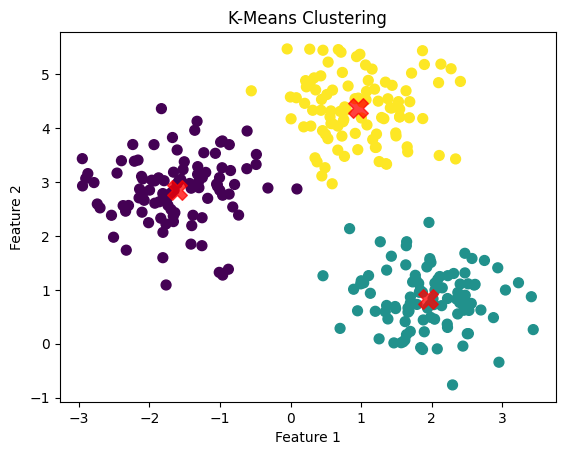

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
X, y_true = datasets.make_blobs(n_samples=300, centers=3, cluster_std=0.60, random_state=0)
kmeans = KMeans(n_clusters=3, random_state=0)
y_kmeans = kmeans.fit_predict(X)
silhouette_avg = silhouette_score(X, y_kmeans)
davies_bouldin = davies_bouldin_score(X, y_kmeans)
print("Silhouette Score: ", silhouette_avg)
print("Davies-Bouldin Score: ", davies_bouldin)

def relabel_clusters(y_true, y_pred):
 label_encoder = LabelEncoder()
 y_true_encoded = label_encoder.fit_transform(y_true)
 cm = confusion_matrix(y_true_encoded, y_pred)
 return np.argmax(cm, axis=1)


relabel_map = relabel_clusters(y_true, y_kmeans)
y_kmeans_mapped = np.array([relabel_map[label] for label in y_kmeans])

print("Confusion Matrix:\n", confusion_matrix(y_true, y_kmeans_mapped))
print("Classification Report:\n", classification_report(y_true, y_kmeans_mapped))
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='X')
plt.title('K-Means Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()
